In [173]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [174]:
df_flight = pd.read_csv('files/Customer Flight Activity.csv')
df_flight.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [175]:
df_loyalty = pd.read_csv('files/Customer Loyalty History.csv')
df_loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


# Fase 1: Exploración y Limpieza

### 1.Exploración Inicial:
### 2.Limpieza de Datos:

In [176]:
df_flight.info()
# Podemos observar en este primer df que no hay nulos y que todos los datos son numericos. (a destacar que los puntos acumulados son float)

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [177]:
df_flight.duplicated().sum()

np.int64(1864)

In [178]:
df_flight[df_flight.duplicated(keep=False)]

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
41,101902,2017,1,0,0,0,0,0.0,0,0
42,101902,2017,1,0,0,0,0,0.0,0,0
226,112142,2017,1,0,0,0,0,0.0,0,0
227,112142,2017,1,0,0,0,0,0.0,0,0
477,126100,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
405111,971370,2018,12,0,0,0,0,0.0,0,0
405409,988392,2018,12,0,0,0,0,0.0,0,0
405410,988392,2018,12,0,0,0,0,0.0,0,0
405436,989528,2018,12,0,0,0,0,0.0,0,0


In [179]:
df_flight.drop_duplicates(keep='first', inplace=True)

In [180]:
df_flight.shape


(403760, 10)

In [181]:
df_flight.isnull().sum()

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
dtype: int64

In [182]:
df_loyalty.info()
#En este data frame si podemos ver que hay nulos y que contiene tanto datos numericos como categoricos

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [183]:
df_loyalty.duplicated().sum()

np.int64(0)

In [184]:
df_loyalty.isnull().sum()/df_loyalty.shape[0]*100

Loyalty Number         0.000000
Country                0.000000
Province               0.000000
City                   0.000000
Postal Code            0.000000
Gender                 0.000000
Education              0.000000
Salary                25.321145
Marital Status         0.000000
Loyalty Card           0.000000
CLV                    0.000000
Enrollment Type        0.000000
Enrollment Year        0.000000
Enrollment Month       0.000000
Cancellation Year     87.650117
Cancellation Month    87.650117
dtype: float64

In [185]:
df_loyalty[df_loyalty['Education'] == 'College']['Salary']

1       NaN
2       NaN
3       NaN
6       NaN
13      NaN
         ..
16721   NaN
16727   NaN
16731   NaN
16732   NaN
16734   NaN
Name: Salary, Length: 4238, dtype: float64

In [186]:
Media_salario= df_loyalty['Salary'].mean()
print(f'La media de salario es {Media_salario}')

La media de salario es 79245.6094087527


In [187]:
Mediana_salario = df_loyalty['Salary'].median()
print(f'La mediana del salario es {Mediana_salario}')

La mediana del salario es 73455.0


In [188]:
# Aun sabiendo que los resultados nulos son todos los clientes con educacion "College?, como el porcentaje de nulos es bajo y la distribucion es asimetrica (media mas grande que mediana) rellenamos con mediana

df_loyalty['Salary']=df_loyalty['Salary'].fillna(Mediana_salario)

In [189]:
df_loyalty.isnull().sum()/df_loyalty.shape[0]*100

Loyalty Number         0.000000
Country                0.000000
Province               0.000000
City                   0.000000
Postal Code            0.000000
Gender                 0.000000
Education              0.000000
Salary                 0.000000
Marital Status         0.000000
Loyalty Card           0.000000
CLV                    0.000000
Enrollment Type        0.000000
Enrollment Year        0.000000
Enrollment Month       0.000000
Cancellation Year     87.650117
Cancellation Month    87.650117
dtype: float64

In [190]:
df_loyalty['Cancellation Year'].unique()

array([  nan, 2018., 2015., 2017., 2014., 2016., 2013.])

In [191]:
df_loyalty['Cancellation Year'] = df_loyalty['Cancellation Year'].fillna('año desconocido')

In [192]:
df_loyalty['Cancellation Month'] = df_loyalty['Cancellation Month'].fillna('mes desconocido')


In [193]:
df_loyalty['Cancellation Month'].unique()

array(['mes desconocido', 1.0, 12.0, 4.0, 2.0, 7.0, 11.0, 5.0, 6.0, 10.0,
       8.0, 9.0, 3.0], dtype=object)

In [194]:
df_loyalty['Loyalty Number'].unique()

array([480934, 549612, 429460, ..., 776187, 906428, 652627],
      shape=(16737,))

In [195]:
df_flight['Loyalty Number'].unique()

array([100018, 100102, 100140, ..., 999731, 999788, 999891],
      shape=(16737,))

In [196]:
df= df_flight.merge(df_loyalty, on=['Loyalty Number'], how='inner')
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,año desconocido,mes desconocido
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,año desconocido,mes desconocido
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,año desconocido,mes desconocido
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,año desconocido,mes desconocido
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,año desconocido,mes desconocido


In [197]:
df.isnull().sum()

Loyalty Number                 0
Year                           0
Month                          0
Flights Booked                 0
Flights with Companions        0
Total Flights                  0
Distance                       0
Points Accumulated             0
Points Redeemed                0
Dollar Cost Points Redeemed    0
Country                        0
Province                       0
City                           0
Postal Code                    0
Gender                         0
Education                      0
Salary                         0
Marital Status                 0
Loyalty Card                   0
CLV                            0
Enrollment Type                0
Enrollment Year                0
Enrollment Month               0
Cancellation Year              0
Cancellation Month             0
dtype: int64

In [198]:
df.duplicated().sum()

np.int64(0)

In [199]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,año desconocido,mes desconocido
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,año desconocido,mes desconocido
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,año desconocido,mes desconocido
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,año desconocido,mes desconocido
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,año desconocido,mes desconocido


In [200]:
df['Points Accumulated'].unique()

array([152.  , 203.  , 120.  , ...,  18.75, 601.  , 626.  ], shape=(1549,))

In [201]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 403760 entries, 0 to 403759
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               403760 non-null  int64  
 1   Year                         403760 non-null  int64  
 2   Month                        403760 non-null  int64  
 3   Flights Booked               403760 non-null  int64  
 4   Flights with Companions      403760 non-null  int64  
 5   Total Flights                403760 non-null  int64  
 6   Distance                     403760 non-null  int64  
 7   Points Accumulated           403760 non-null  float64
 8   Points Redeemed              403760 non-null  int64  
 9   Dollar Cost Points Redeemed  403760 non-null  int64  
 10  Country                      403760 non-null  str    
 11  Province                     403760 non-null  str    
 12  City                         403760 non-null  str    
 13  Postal Cod

In [202]:
#En la primera fase realizamos una exploración de ambas bases de datos y observamos que la primera tabla tiene duplicados y la segunda tiene nulos. Decido arreglarlas por separado antes de mezclarlas y hacer un merge 'inner' para quedarnos con todos los datos de los clientes de las dos tablas

## Fase 2: Análisis Estadístico

### 1.Análisis de variables numéricas:

In [203]:
df.describe().T



,count,mean,std,min,25%,50%,75%,max
Loyalty Number,403760.0,549875.383713,258961.514684,100018.00,326699.00,550598.00,772152.00,999986.00
Year,403760.0,2017.500352,0.500000,2017.00,2017.00,2018.00,2018.00,2018.00
Month,403760.0,6.501335,3.451982,1.00,4.00,7.00,10.00,12.00
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Flights with Companions,403760.0,1.036569,2.080472,0.00,0.00,0.00,1.00,11.00
Total Flights,403760.0,5.170619,6.526858,0.00,0.00,1.00,10.00,32.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Points Redeemed,403760.0,30.838587,125.758002,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,403760.0,2.495973,10.172033,0.00,0.00,0.00,0.00,71.00


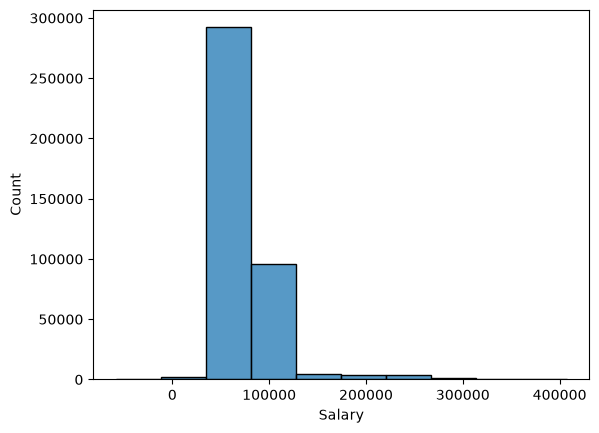

In [204]:
#veo por encima que hay un salario que es negativo
sns.histplot(data=df, x='Salary', bins=10)
plt.show()

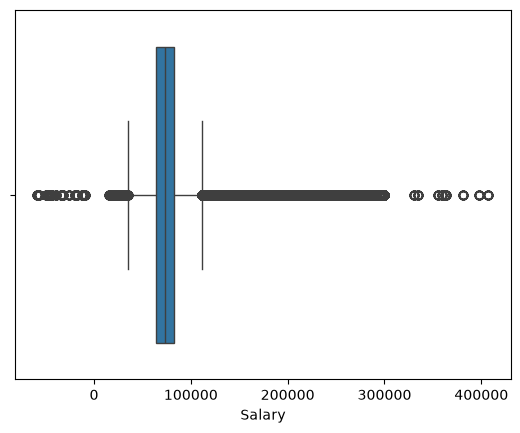

In [205]:
sns.boxplot(data=df, x='Salary')
plt.show()

In [206]:
df[df['Salary'] < 0]

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
291,115505,2017,1,0,0,0,0,0.0,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-10605.0,Married,Nova,5860.17,2018 Promotion,2018,4,año desconocido,mes desconocido
956,152016,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1J 8T7,Female,Bachelor,-58486.0,Married,Aurora,5067.21,2018 Promotion,2018,2,año desconocido,mes desconocido
1716,194065,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Sudbury,M5V 1G5,Female,Bachelor,-31911.0,Married,Nova,2888.85,2018 Promotion,2018,2,año desconocido,mes desconocido
2081,212128,2017,1,3,0,3,1959,195.0,0,0,Canada,Ontario,Toronto,P2T 6G3,Male,Bachelor,-49001.0,Married,Nova,3130.68,2018 Promotion,2018,2,año desconocido,mes desconocido
2433,232755,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V1E 4R6,Female,Bachelor,-46683.0,Single,Nova,4787.81,2018 Promotion,2018,3,año desconocido,mes desconocido
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
398813,734647,2018,12,15,0,15,1440,144.0,0,0,Canada,Saskatchewan,Regina,S1J 3C5,Male,Bachelor,-46303.0,Married,Nova,11280.73,2018 Promotion,2018,4,año desconocido,mes desconocido
399884,790475,2018,12,7,1,8,1056,105.0,0,0,Canada,Ontario,Trenton,K8V 4B2,Female,Bachelor,-34079.0,Married,Nova,12913.50,2018 Promotion,2018,2,año desconocido,mes desconocido
402017,906428,2018,12,13,0,13,2912,291.0,0,0,Canada,Yukon,Whitehorse,Y2K 6R0,Male,Bachelor,-57297.0,Married,Star,10018.66,2018 Promotion,2018,4,año desconocido,mes desconocido
402459,430398,2018,12,5,5,10,660,66.0,539,44,Canada,Newfoundland,St. John's,A1C 6H9,Male,Bachelor,-17534.0,Married,Nova,49423.80,2018 Promotion,2018,3,año desconocido,mes desconocido


In [207]:
df['Salary']= df['Salary'].abs()

array([[<Axes: title={'center': 'Loyalty Number'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Month'}>,
        <Axes: title={'center': 'Flights Booked'}>],
       [<Axes: title={'center': 'Flights with Companions'}>,
        <Axes: title={'center': 'Total Flights'}>,
        <Axes: title={'center': 'Distance'}>,
        <Axes: title={'center': 'Points Accumulated'}>],
       [<Axes: title={'center': 'Points Redeemed'}>,
        <Axes: title={'center': 'Dollar Cost Points Redeemed'}>,
        <Axes: title={'center': 'Salary'}>,
        <Axes: title={'center': 'CLV'}>],
       [<Axes: title={'center': 'Enrollment Year'}>,
        <Axes: title={'center': 'Enrollment Month'}>, <Axes: >, <Axes: >]],
      dtype=object)

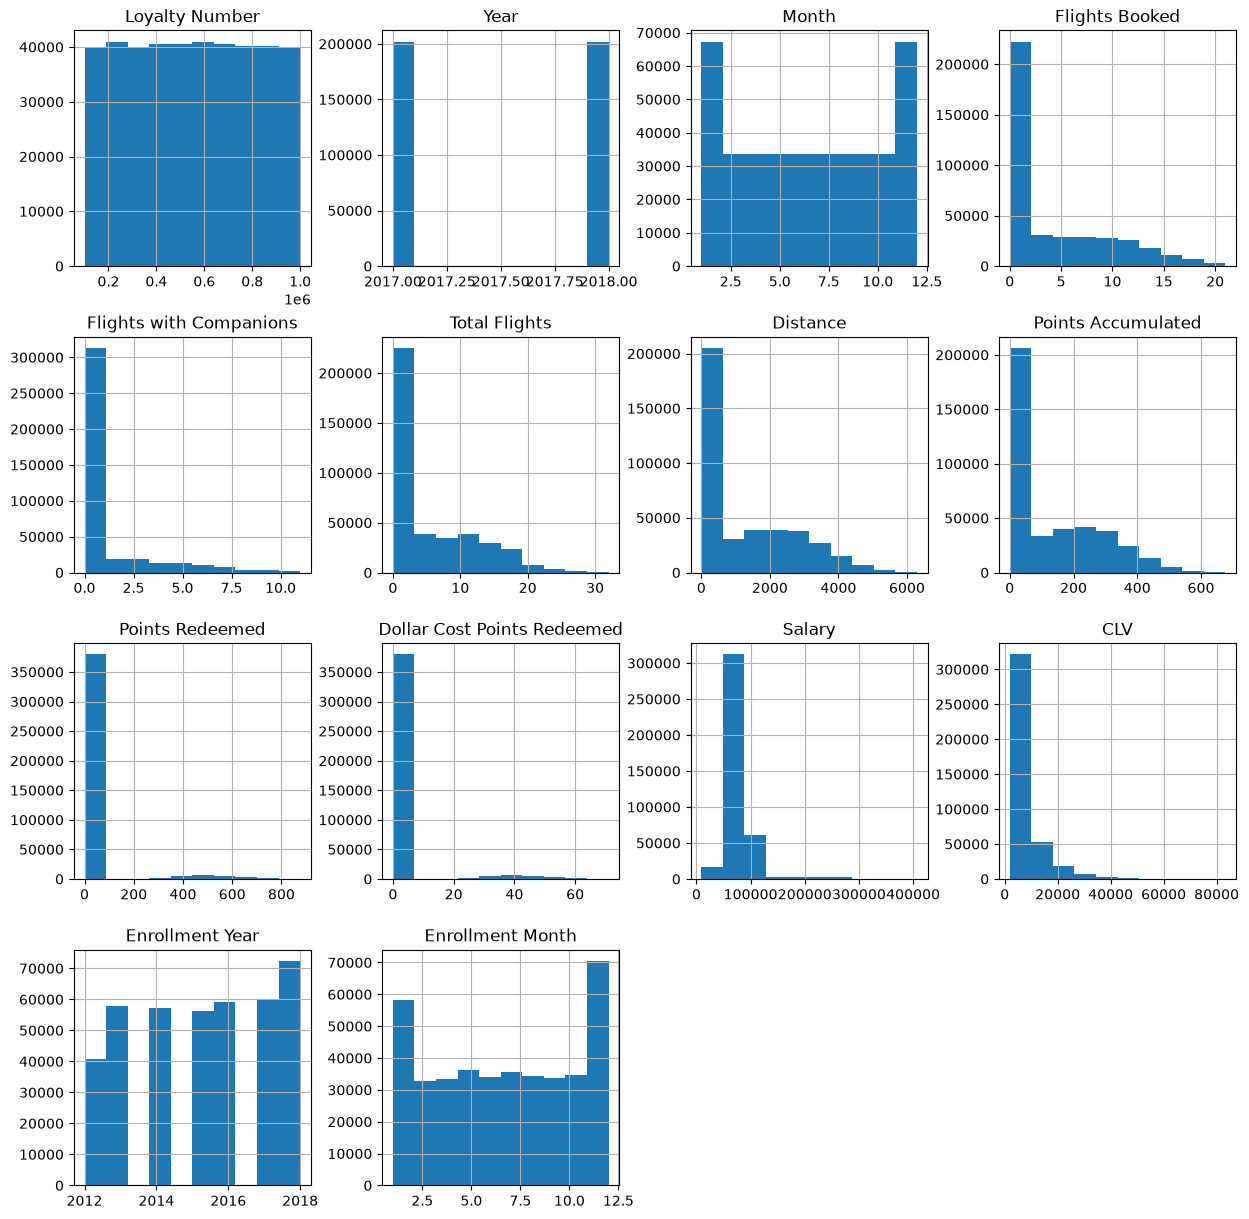

In [208]:
df.hist(figsize=(15, 15))

<Axes: xlabel='Salary', ylabel='Total Flights'>

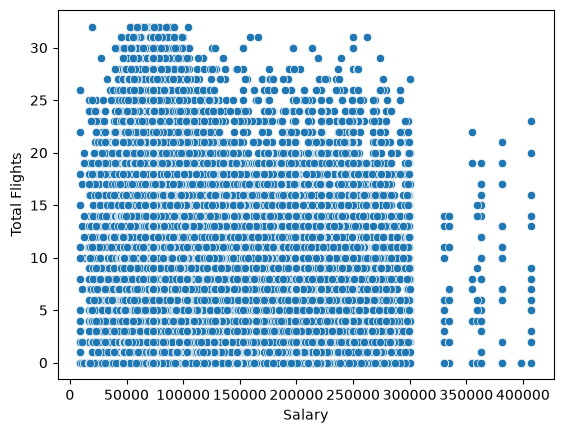

In [209]:
sns.scatterplot(data=df, x='Salary', y='Total Flights')

<Axes: xlabel='Distance', ylabel='Points Accumulated'>

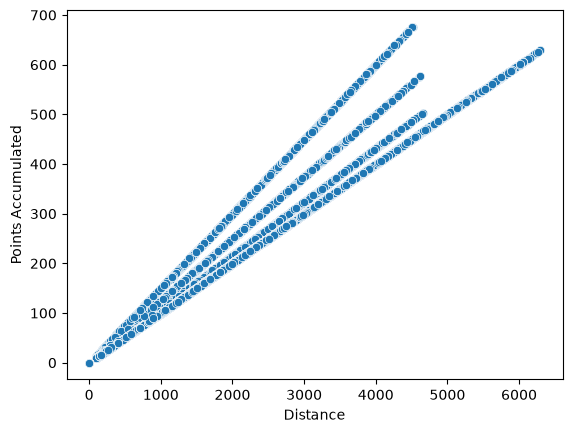

In [210]:
sns.scatterplot(data=df, x='Distance', y='Points Accumulated')

<Axes: >

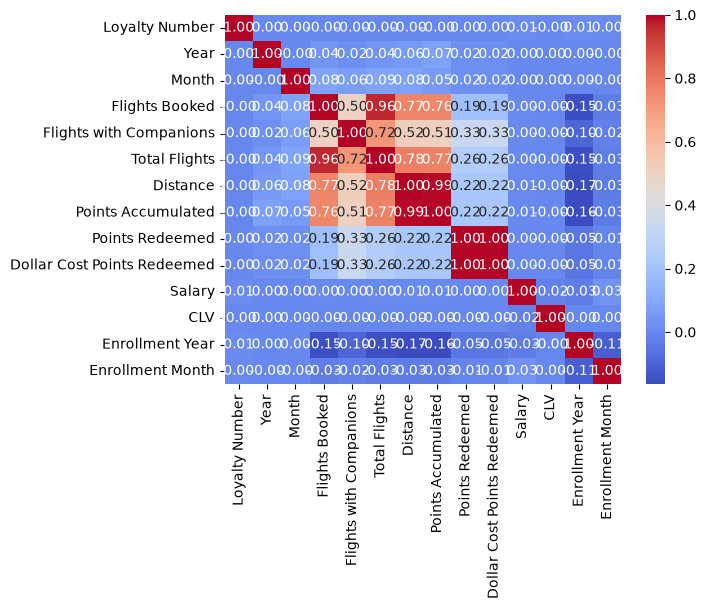

In [211]:
num = df.select_dtypes(include=np.number).columns
matriz= df[num].corr()
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt='.2f')

In [212]:
num = df.select_dtypes(include=np.number).columns
for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    iqr = Q3 - Q1
    lower = Q1 - 1.5 * iqr
    upper = Q3 + 1.5 * iqr
    outliers = df[(df[col] < lower)|(df[col] > upper)]
    print(col, outliers.shape[0])

Loyalty Number 0
Year 0
Month 0
Flights Booked 528
Flights with Companions 71560
Total Flights 1984
Distance 125
Points Accumulated 112
Points Redeemed 24181
Dollar Cost Points Redeemed 24181
Salary 20876
CLV 35941
Enrollment Year 0
Enrollment Month 0


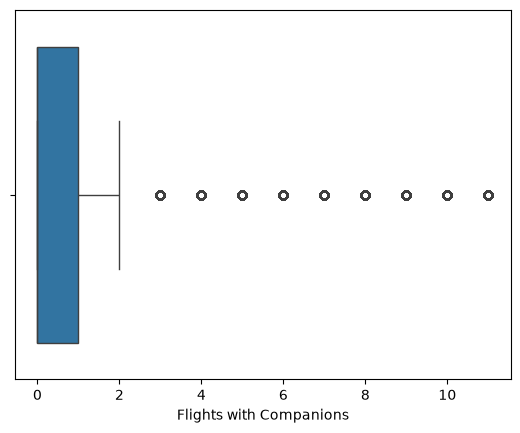

In [213]:
sns.boxplot(data=df, x='Flights with Companions')
plt.show()

In [214]:
# En el primer analisis de las variables númericas podemos ver que tenemos salarios en negativo, seguramente por un error de transcripción y procedemos a usar el codigo .abs() para que nos devuelva el numero absoluto del salario por debajo del 0.
# A partir de aqui empezamos a visualizar si hay correlaciones entre las diferentes columnas. En este caso podemos ver que el Salario no es determinante a la hora del nº de vuelos de cada cliente y en el heatmap vemos que las correlaciones suelen ir determinadas por la cantidad vuelos con los puntos acumulados, o la distancia con el numero de vuelos
# Respecto a los outliers, podemos observar varios de ellos en las variables y que muchos no son errores sino clientes reales con valores altos, por lo tanto decido no eliminarlos y trabajar con ellos

### 2.Análisis de variables categóricas:

In [215]:
categoricas = df.select_dtypes(include='object')

In [216]:
categoricas

,Country,Province,City,Postal Code,Gender,Education,Marital Status,Loyalty Card,Enrollment Type,Cancellation Year,Cancellation Month
0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,Married,Aurora,Standard,año desconocido,mes desconocido
1,Canada,Ontario,Toronto,M1R 4K3,Male,College,Single,Nova,Standard,año desconocido,mes desconocido
2,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,Divorced,Nova,Standard,año desconocido,mes desconocido
3,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,Married,Star,Standard,año desconocido,mes desconocido
4,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,Divorced,Star,Standard,año desconocido,mes desconocido
...,...,...,...,...,...,...,...,...,...,...,...
403755,Canada,Ontario,Toronto,M1R 4K3,Male,College,Married,Aurora,Standard,año desconocido,mes desconocido
403756,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,Single,Nova,Standard,año desconocido,mes desconocido
403757,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,Married,Nova,Standard,año desconocido,mes desconocido
403758,Canada,British Columbia,Victoria,V10 6T5,Male,College,Married,Star,Standard,año desconocido,mes desconocido


In [217]:
categoricas['Country'].unique()

<ArrowStringArray>
['Canada']
Length: 1, dtype: str

In [218]:
orden=df['Gender'].value_counts()
orden

Gender
Female    202757
Male      201003
Name: count, dtype: int64

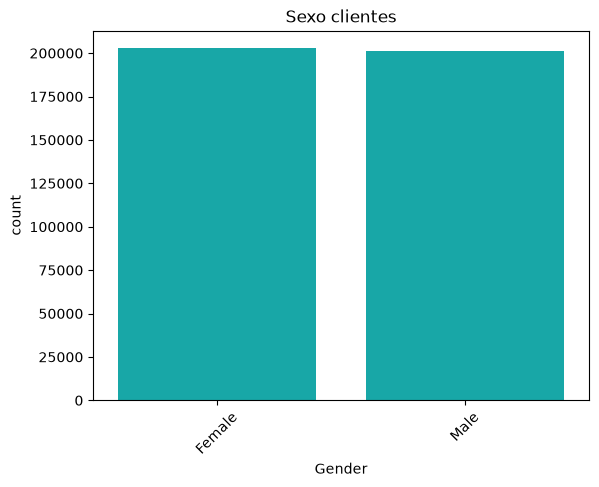

In [219]:
orden=df['Gender'].value_counts().index

sns.countplot(x='Gender', data=df, color='c', order=orden)
plt.xticks(rotation=45)
plt.title('Sexo clientes')
plt.show()

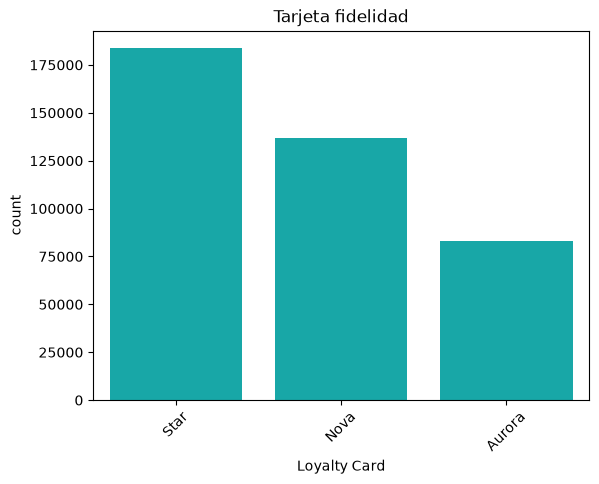

In [220]:
orden=df['Loyalty Card'].value_counts().index

sns.countplot(x='Loyalty Card', data=df, color='c', order=orden)
plt.xticks(rotation=45)
plt.title('Tarjeta fidelidad')
plt.show()

In [221]:
# absoluta (conteo)
frecuencia_absoluta_edu = df['Education'].value_counts()

In [222]:
# relativa (%)
frecuencia_relativa_edu = df['Education'].value_counts(normalize=True) * 100

In [223]:
tabla_frecuencias = pd.DataFrame({
  'Education': frecuencia_absoluta_edu.index,
  'frecuencia_absoluta': frecuencia_absoluta_edu.values,
  'frecuencia_relativa': frecuencia_relativa_edu.values})

In [224]:
tabla_frecuencias

,Education,frecuencia_absoluta,frecuencia_relativa
0,Bachelor,252567,62.553745
1,College,102260,25.326927
2,High School or Below,18915,4.684714
3,Doctor,17731,4.391470
4,Master,12287,3.043144


In [225]:
# absoluta (conteo)
frecuencia_absoluta_ms = df['Marital Status'].value_counts()
# relativa (%)
frecuencia_relativa_ms = df['Marital Status'].value_counts(normalize=True) * 100
tabla_frecuencias = pd.DataFrame({
  'Marital Status': frecuencia_absoluta_ms.index,
  'frecuencia_absoluta': frecuencia_absoluta_ms.values,
  'frecuencia_relativa': frecuencia_relativa_ms.values})
tabla_frecuencias

,Marital Status,frecuencia_absoluta,frecuencia_relativa
0,Married,234845,58.164504
1,Single,108153,26.786457
2,Divorced,60762,15.049039


In [226]:
    # En el analisis de las variables categoricas revisamos las mas relevantes, como por ejemplo el sexo de los clientes vemos que es bastante equitativo y que las abundan más unas tarjetas de fidelizacion que otras.
    # En las tablas de frecuencia revisamos el estado civil y podemos observar que mas del 50% estan casados y que alrededor del 15% estan divorciados, lo que indica que el perfil de cliente predominante es el de personas casadas.

# Fase 3: Visualización

In [227]:
#1:¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

In [228]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,año desconocido,mes desconocido
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,año desconocido,mes desconocido
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,año desconocido,mes desconocido
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,año desconocido,mes desconocido
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,año desconocido,mes desconocido


In [229]:
vuelos_por_mes = df.groupby('Month')['Flights Booked'].sum()
vuelos_por_mes

Month
1      96936
2      96334
3     131199
4     112511
5     142170
6     173242
7     193431
8     169204
9     136379
10    129461
11    122250
12    166047
Name: Flights Booked, dtype: int64

In [230]:
vuelos_por_mes.values

array([ 96936,  96334, 131199, 112511, 142170, 173242, 193431, 169204,
       136379, 129461, 122250, 166047])

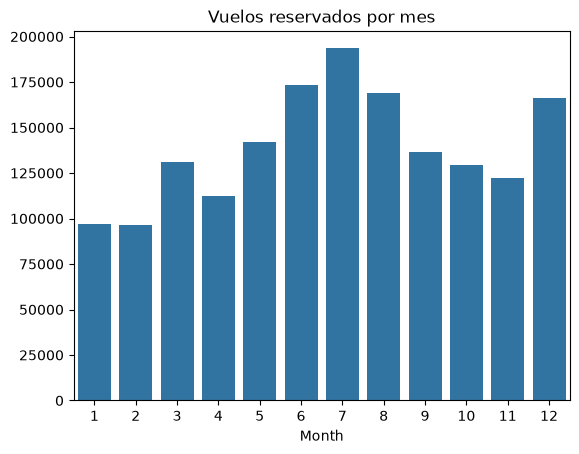

In [231]:
sns.barplot(x=vuelos_por_mes.index, y=vuelos_por_mes.values)
plt.title('Vuelos reservados por mes')
plt.show()

In [232]:
# En la distribucion de cantidad vuelos por mes, podemos observar que los clientes suelen viajar más en los meses de junio, julio y agosto, coincidiendo en temporada de vacaciones y verano. Y por otro lado el mes de diciembre tambien destaca por ser temporada navideña.
# La aerolina puede adaptar sus precios y volumen de aviones para estas fechas mas predominantes.

In [233]:
#2. ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

In [234]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,año desconocido,mes desconocido
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,año desconocido,mes desconocido
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,año desconocido,mes desconocido
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,año desconocido,mes desconocido
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,año desconocido,mes desconocido


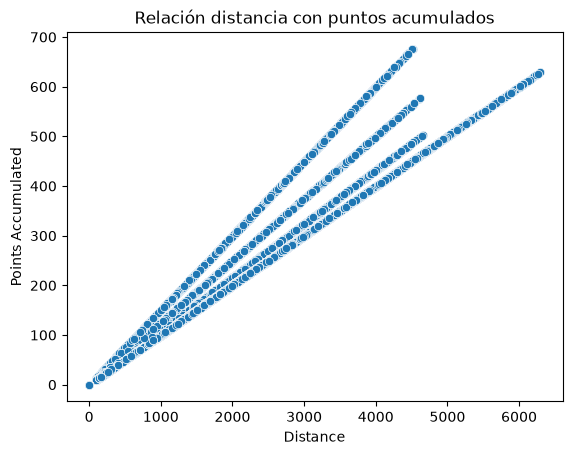

In [235]:
sns.scatterplot(data=df, x='Distance', y='Points Accumulated')
plt.title('Relación distancia con puntos acumulados')
plt.show()

In [236]:
# En la relacion de las variables "distancia" y "puntos acumulados" podemos interpretar que efectivamente existe esta relación de cuanta mas distancia mas puntos acumulas en tu tarjeta de fidelizacion.

In [237]:
#3. ¿Cuál es la distribución de los clientes por provincia o estado?

In [238]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,año desconocido,mes desconocido
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,año desconocido,mes desconocido
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,año desconocido,mes desconocido
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,año desconocido,mes desconocido
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,año desconocido,mes desconocido


In [239]:
df_clientes_unicos = df.drop_duplicates(subset=['Loyalty Number'])

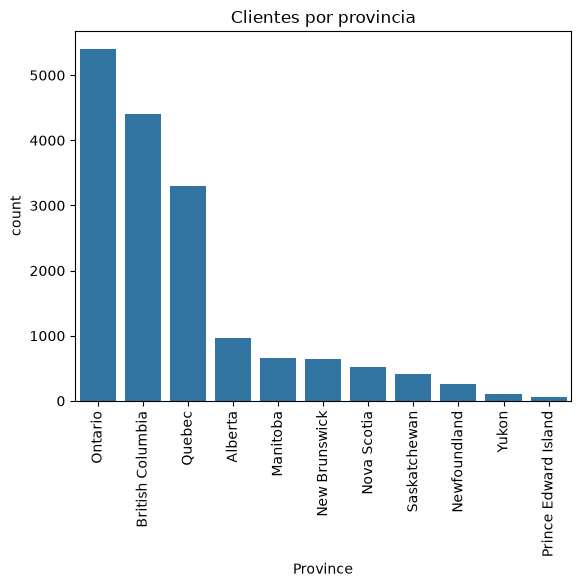

In [240]:
orden = df_clientes_unicos['Province'].value_counts().index

sns.countplot(x='Province', data=df_clientes_unicos, order=orden)
plt.xticks(rotation=90)
plt.title('Clientes por provincia')
plt.show()

In [241]:
# En la distribucion de clientes por provincia, podemos ver claramente que los clientes son de las grandes provincias de Canada: Ontario, British Columbia y Quebec.

In [242]:
#4. ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

In [243]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,año desconocido,mes desconocido
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,año desconocido,mes desconocido
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,año desconocido,mes desconocido
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,año desconocido,mes desconocido
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,año desconocido,mes desconocido


In [244]:
df_clientes_unicos.groupby('Education')['Salary'].mean()

Education
Bachelor                 72577.254415
College                  73455.000000
Doctor                  178608.897820
High School or Below     61199.161125
Master                  103757.848425
Name: Salary, dtype: float64

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Bachelor'),
  Text(1, 0, 'College'),
  Text(2, 0, 'Master'),
  Text(3, 0, 'High School or Below'),
  Text(4, 0, 'Doctor')])

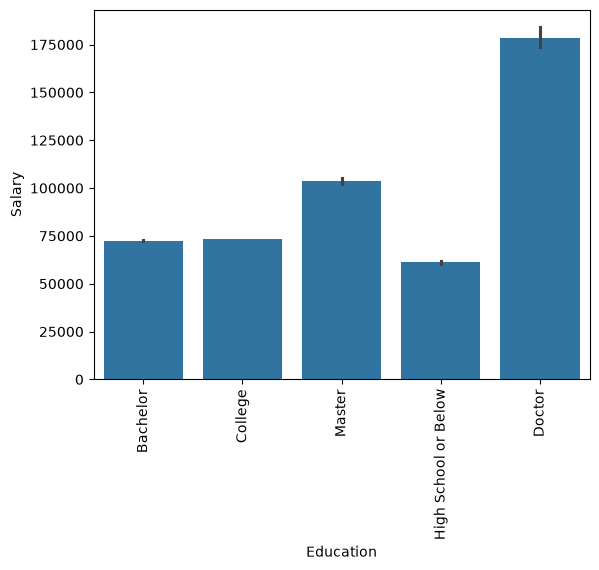

In [245]:
sns.barplot(x='Education', y='Salary', data=df_clientes_unicos)
plt.xticks(rotation=90)

In [246]:
# En la comparacion del salario promedio entre los diferentes estudios podemos ver una gran diferencia de educacion, en la cual predomino mejor salario a los clientes con doctorados.
# Cabe destacar que soy consciente que en la base de datos todos los nulos eran de clientes con estudios College y por lo tanto no podemos verificar el salario de estos clientes.

In [247]:
#5. ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?


In [248]:
df_tarta = df_clientes_unicos.groupby('Loyalty Card')['Loyalty Number'].count().reset_index()

In [249]:
df_tarta

,Loyalty Card,Loyalty Number
0,Aurora,3429
1,Nova,5671
2,Star,7637


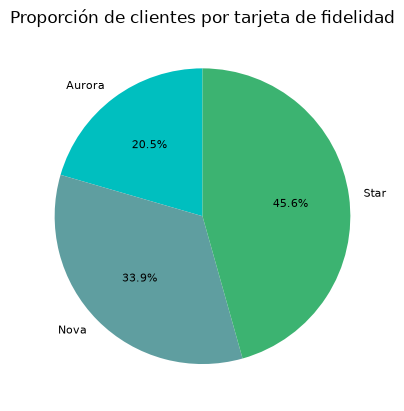

In [250]:
colores = ['c', 'cadetblue', 'mediumseagreen']

plt.pie('Loyalty Number',
#columna con las cantidades
    data=df_tarta,
    labels=df_tarta['Loyalty Card'], 
# el nombre de cada porción
    autopct='%1.1f%%',    
# mostrar el porcentaje con 1 decimal
    colors=colores,
    textprops={'fontsize': 8},
    startangle=90)      
# girar para que empiece arriba
plt.title('Proporción de clientes por tarjeta de fidelidad')
plt.show()

In [251]:
# En la proporcion de clientes por tarjeta de fidelidad podemos comprobar que Star es la tarjeta más extendida (45,6%), seguida de Nova (33,9%) y Aurora (20,5%)

In [252]:
#6. ¿Cómo se distribuyen los clientes según su estado civil y género?

In [253]:
df.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,año desconocido,mes desconocido
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73455.0,Single,Nova,2887.74,Standard,2013,3,año desconocido,mes desconocido
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73455.0,Divorced,Nova,2838.07,Standard,2016,7,año desconocido,mes desconocido
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,año desconocido,mes desconocido
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,año desconocido,mes desconocido


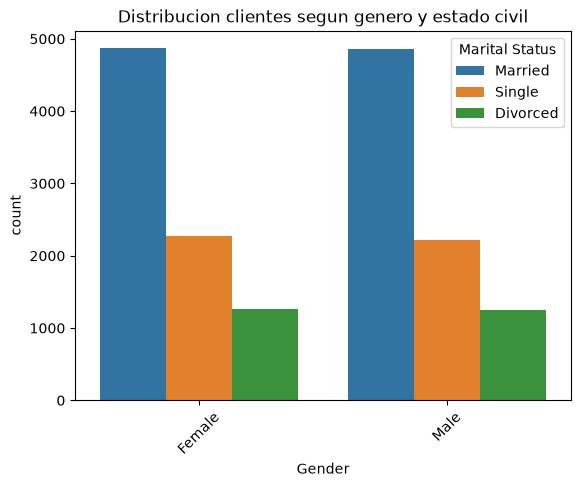

In [254]:
orden_gender = df_clientes_unicos['Gender'].value_counts().index

sns.countplot(x='Gender', data=df_clientes_unicos, order=orden_gender, hue='Marital Status')
plt.xticks(rotation=45)
plt.title('Distribucion clientes segun genero y estado civil')
plt.show()

In [255]:
# En esta ultima visualizacion podemos comprobar que la distribucion de clientes segun genero y estado civil es practicamente igual. 
# en ambos géneros predominan los casados, seguidos de solteros y divorciados ,por lo tanto no hay diferencias significativas entre hombres y mujeres en cuanto a estado civil.

# Fase 4: Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo

In [256]:
df_fb_edu = df[['Flights Booked', 'Education']]

In [257]:
df_fb_edu

,Flights Booked,Education
0,3,Bachelor
1,10,College
2,6,College
3,0,Bachelor
4,0,Bachelor
...,...,...
403755,0,College
403756,0,Doctor
403757,3,Bachelor
403758,0,College


In [258]:
df_fb_edu.groupby('Education')['Flights Booked'].agg(['mean', 'std']).reset_index()

,Education,mean,std
0,Bachelor,4.110288,5.221671
1,College,4.169744,5.246040
2,Doctor,4.175512,5.256971
3,High School or Below,4.176209,5.239267
4,Master,4.200700,5.213956


In [ ]:
# En la evaluacion de diferencias en reservas de vuelo por educacion observamos que la media de vuelos reservados por educaicon es muy parecida entre ellos y por lo tanto la desviacion estandar tambien. 
# De tal manera que podemos afirmar que el nivel educativo de los clientes no es relevante a la hora de reservar vuelos.